```text
Capital analysis
├── Import & Setup
├── PD and LGD estimation
└── Capital estimation (Monte-Carlo)
    ├── Capital concentration - on PD x LGD
    ├── Capital concentration - on PD 
    └── Capital reduction    
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import aggregate_el_on_pd, estimate_capital_reduction, show_approval_vs_reduction
from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe_PD, apply_pipe_LGD, estimate_capital
from src.plots import plot_loss_distribution, plot_heatmap
from src.preprocessing import input_load
from src.validation import validate_predictions

# Dataset specific settings

from src import settings

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = input_load(2019, 2020)
portfolio, dr_summary = create_target_def12(portfolio)

## PD and LGD estimation

In [4]:
# import pipelines

import joblib
pipeline_pd  = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_lgd = joblib.load("../models/PIPELINE_LGD_Amount.pkl")

In [5]:
# apply pipelines

portfolio = apply_pipe_PD(portfolio, pipeline_pd)
portfolio = apply_pipe_LGD(portfolio, pipeline_lgd)

In [6]:
# validate model output

validate_predictions(portfolio)

----------------------------------------
MODEL OUTPUT VALIDATION
----------------------------------------


,PD,LGD
Min,0.000,0.000
Mean,0.150,0.132
Max,0.595,0.224
NaNs,0.000,0.000


,PD,LGD
Min,2.284632e-18,0.000000
Mean,1.499553e-01,0.132040
Max,5.948402e-01,0.224033
NaNs,0.000000e+00,0.000000


## Capital estimation (Monte-Carlo)

#### Capital concentration - on PD x LGD

selected variable:  EL
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.029282  0.043009  0.058625  0.085654  0.145875
50–70%   0.035146  0.072426  0.105585  0.144007  0.259950
70–100%  0.000582  0.001784  0.004046  0.006260  0.007769


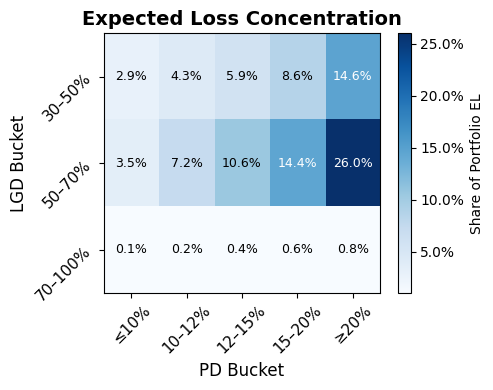

selected variable:  CAP
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.028848  0.042679  0.056345  0.084343  0.143020
50–70%   0.035381  0.069449  0.107718  0.146491  0.262292
70–100%  0.001052  0.002166  0.004326  0.007598  0.008290


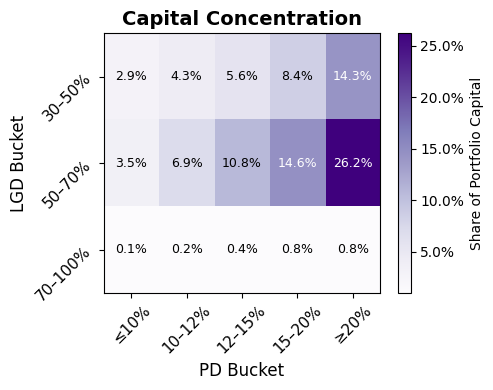

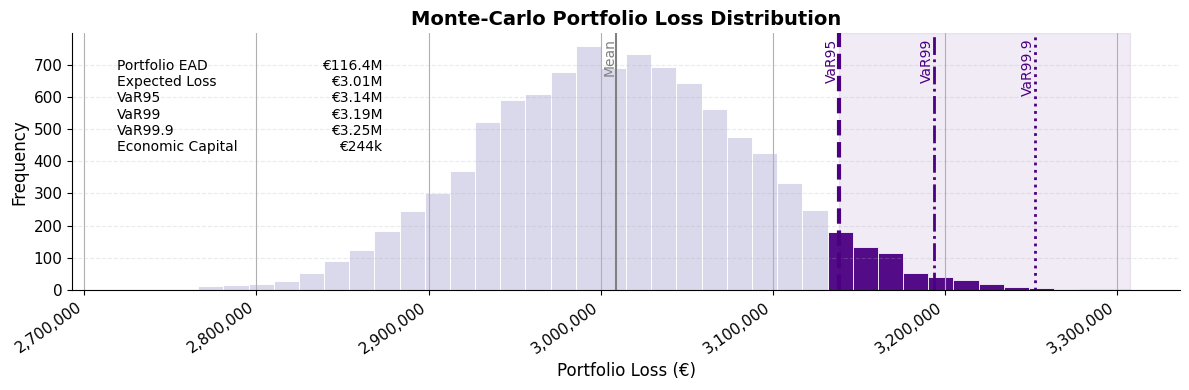

In [7]:
# capital estimation 'monte-carlo' with observed LGDs

capital_montecarlo, _, _, simulated_losses= estimate_capital(portfolio, method="monte-carlo", column_lgd="LossGivenDefault", allocate=True, verbose=False)
heatmap_EL = plot_heatmap(capital_montecarlo, variable="EL" , column_lgd="LossGivenDefault")
heatmap_CA = plot_heatmap(capital_montecarlo, variable="CAP", column_lgd="LossGivenDefault")
fig = plot_loss_distribution(simulated_losses, portfolio[settings.COLUMN_EAD].sum(), show_plot=True)

#### Capital concentration - on PD

In [8]:
bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

table_EL   = aggregate_el_on_pd(capital_montecarlo, "EL"   , bins)
table_CAP  = aggregate_el_on_pd(capital_montecarlo, "CAP"  , bins)

#### Capital reduction

running Monte-Carlo...  PD threshold:  1.0
running Monte-Carlo...  PD threshold:  0.25
running Monte-Carlo...  PD threshold:  0.2
running Monte-Carlo...  PD threshold:  0.15
running Monte-Carlo...  PD threshold:  0.1
running Monte-Carlo...  PD threshold:  0.08
running Monte-Carlo...  PD threshold:  0.05


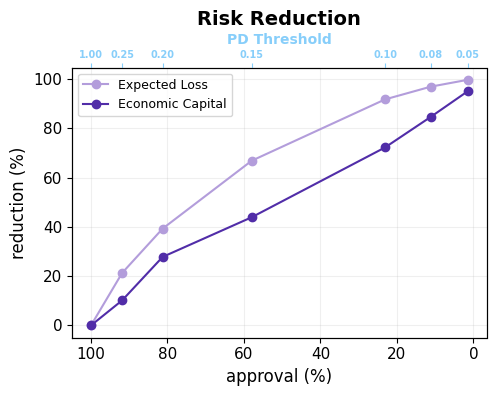

In [9]:
# how do expected loss and economic capital respond 
# to a decreasing PD acceptance threshold

pd_thresholds = [1.00, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05]
est_reduction = estimate_capital_reduction(portfolio, pd_thresholds)
show = show_approval_vs_reduction(est_reduction, invert_y=False)